# 02 · Sampler anatomy

Six ways to steer a diffusion sampler, measured against exact targets.

* **oracle**: draws from the exact posterior (the finite-N floor reference).
* **plug-in guidance (DPS-class)**: nudges each denoising step with the data
  gradient through a point estimate. Cheap, ubiquitous, no guarantee.
* **reward-as-potential SMC**: a particle population resampled every step on
  the reward. Improper by construction (the tilt compounds with depth).
* **twisted SMC**: the properly weighted particle method, with the optimal
  twist available in closed form on this bench.
* **terminal reweighting**: unguided samples, importance-reweighted once at
  the end.
* **inflated-noise annealed Langevin**: a ladder of noise levels with K
  Langevin corrections per level, the data pull deliberately weakened while
  the map is still noisy.

The mechanism at the heart of the first result deserves its equation. At step
time $t$ the exact data pull on mode $k$ is

$$g^{\mathrm{exact}}_k \;=\; \nabla_z \log
\mathcal{N}\!\big(y_k;\; a_k \hat{x}_k(z),\; b + a_k^2\, v_k(t)\big),$$

while plug-in guidance uses the same expression **without** the
$a_k^2 v_k(t)$ term. **In words:** the exact pull discounts the data early in
generation, when the current estimate $\hat{x}$ is still uncertain by
$v_k(t)$. The plug-in shortcut trusts its point estimate completely at every
step, so it over-pulls early and locks in overconfident structure. Everything
in the first figure follows from that one missing term.

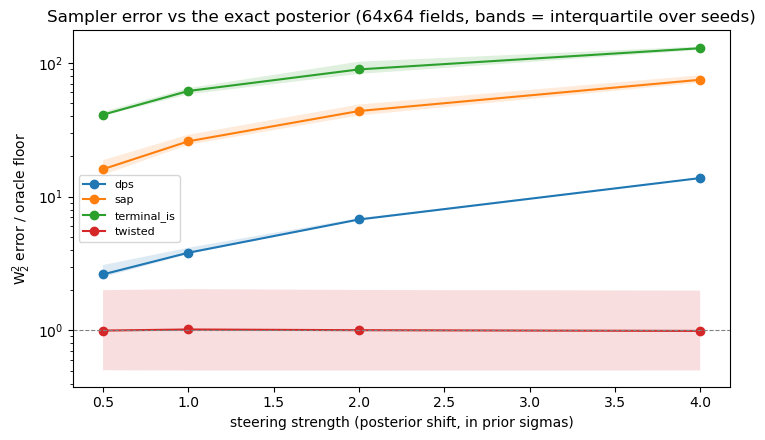

In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
RES = ROOT / "results"

def rows(name):
    p = RES / name
    if not p.exists():
        print(f"({name} not found, cell skipped)")
        return []
    return [json.loads(l) for l in p.open()]

t1 = [r for r in rows("t1_core.jsonl") if r.get("dim") == 64
      and r.get("eps", 0) == 0]
by = defaultdict(list)
floors = defaultdict(list)
for r in t1:
    if r["sampler"] == "oracle":
        floors[r["shift"]].append(r["w2"])
for r in t1:
    if r["sampler"] != "oracle":
        by[(r["sampler"], r["shift"])].append(r["w2"])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for s in sorted({k[0] for k in by}):
    shifts = sorted({k[1] for k in by if k[0] == s})
    ratios = [np.median(by[(s, sh)]) / np.median(floors[sh]) for sh in shifts]
    lo = [np.quantile(np.array(by[(s, sh)]) / np.median(floors[sh]), 0.25)
          for sh in shifts]
    hi = [np.quantile(np.array(by[(s, sh)]) / np.median(floors[sh]), 0.75)
          for sh in shifts]
    ax.plot(shifts, ratios, "o-", label=s)
    ax.fill_between(shifts, lo, hi, alpha=0.15)
ax.axhline(1, color="gray", lw=0.8, ls="--")
ax.set_yscale("log")
ax.set_xlabel("steering strength (posterior shift, in prior sigmas)")
ax.set_ylabel("W$_2^2$ error / oracle floor")
ax.set_title("Sampler error vs the exact posterior (64x64 fields, "
             "bands = interquartile over seeds)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the figure.** Each line is one sampler, each point a steering
strength, the shaded band the interquartile range over random seeds. The
properly weighted method (twisted) sits on the floor, as theory demands on
this conjugate bench, which makes it the control that validates the harness
rather than a finding. Plug-in guidance (dps) is substantially and
monotonically biased. The resampling shortcut (sap) and terminal reweighting
degrade faster. The dps curve was additionally confirmed by an independent
closed-form calculation (a stiff-ODE integration of the guided dynamics per
mode) that reproduces the measured grid to 1 to 3 percent, so the mechanism
is understood, not just observed.

## The anatomy of the bias

Two views of the same error, from the same rows. Left, the **width story**:
the median log-ratio of sampler width to true width per mode (0 means correct
widths, negative means overconfident). Right, **what that costs**: how often
the true map falls inside the sampler's central 68% interval. The honest
value is 0.68.

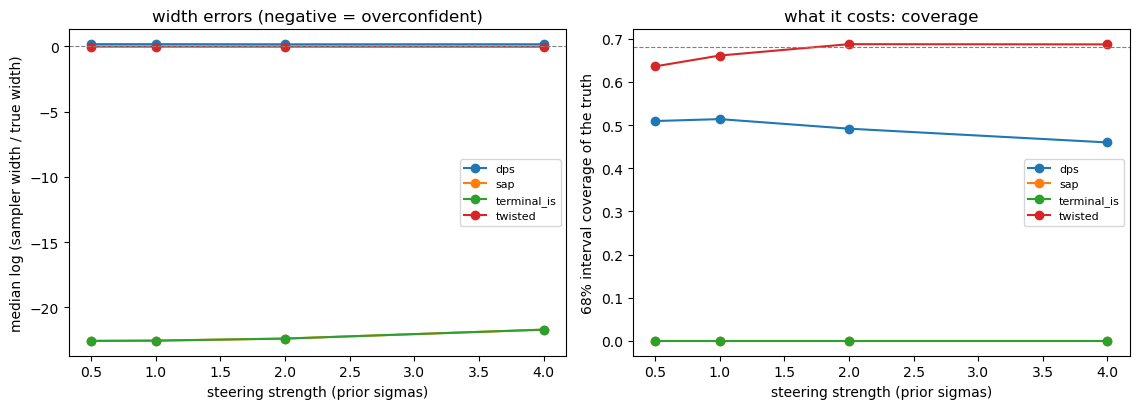

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for s in sorted({k[0] for k in by}):
    shifts = sorted({k[1] for k in by if k[0] == s})
    vr = [np.median([r["var_ratio_logmed"] for r in t1
                     if r["sampler"] == s and r["shift"] == sh])
          for sh in shifts]
    cov = [np.median([r["cov_mean_68"] for r in t1
                      if r["sampler"] == s and r["shift"] == sh])
           for sh in shifts]
    axes[0].plot(shifts, vr, "o-", label=s)
    axes[1].plot(shifts, cov, "o-", label=s)
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].set_ylabel("median log (sampler width / true width)")
axes[0].set_title("width errors (negative = overconfident)")
axes[1].axhline(0.68, color="gray", lw=0.8, ls="--")
axes[1].set_ylabel("68% interval coverage of the truth")
axes[1].set_title("what it costs: coverage")
for ax in axes:
    ax.set_xlabel("steering strength (prior sigmas)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the panels.** dps loses width steadily as steering grows and
its coverage collapses far below 0.68: error bars that look precise and are
simply wrong. sap collapses much harder. The twisted control holds both
dashed lines, which is what "the harness is sound" looks like in this view.

## Two scaling laws worth knowing

Left: the plug-in bias is **extensive in dimension**. The same experiment at
16x16, 32x32, and 64x64 (256 to 4,096 modes), at fixed steering strength: the
floor-relative error keeps growing with resolution, so bigger maps make the
problem worse, not better. Right: the resampling shortcut's pathology is
**depth-dependent**. Its effective tilt exponent $\gamma^*$ (the steering
strength the samples actually express, recovered by fitting the per-mode
widths, 1 means faithful) rises with the number of steps T, because its
potentials compound at every resampling.

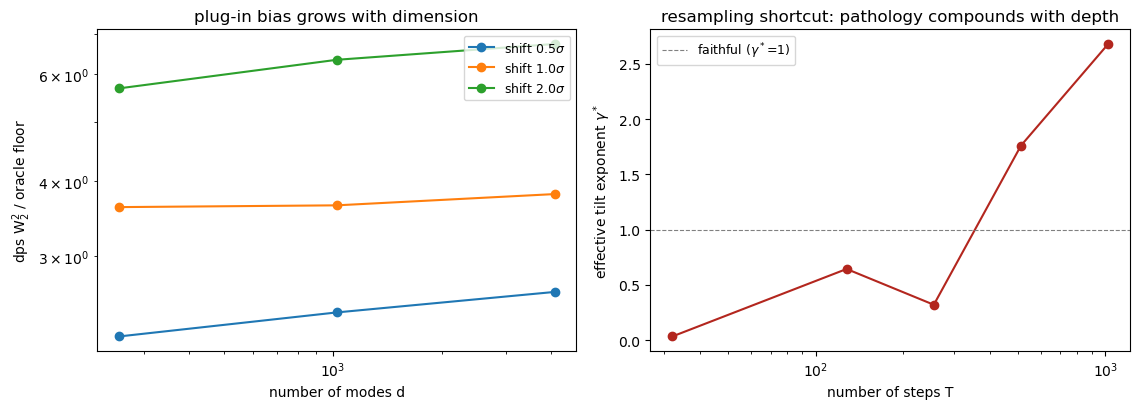

In [3]:
t1all = [r for r in rows("t1_core.jsonl") if r.get("eps", 0) == 0]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
for sh in (0.5, 1.0, 2.0):
    dims, vals = [], []
    for dim in (16, 32, 64):
        dps_w = [r["w2"] for r in t1all if r["sampler"] == "dps"
                 and r["dim"] == dim and r["shift"] == sh]
        orc_w = [r["w2"] for r in t1all if r["sampler"] == "oracle"
                 and r["dim"] == dim and r["shift"] == sh]
        if dps_w and orc_w:
            dims.append(dim * dim)
            vals.append(np.median(dps_w) / np.median(orc_w))
    ax.plot(dims, vals, "o-", label=f"shift {sh}$\sigma$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of modes d")
ax.set_ylabel("dps W$_2^2$ / oracle floor")
ax.set_title("plug-in bias grows with dimension")
ax.legend(fontsize=9)

ax = axes[1]
ts = rows("t1_tsens.jsonl")
byT = defaultdict(list)
for r in ts:
    if r["sampler"] == "sap":
        byT[r["T"]].append(r["gamma_star"])
Ts = sorted(byT)
ax.plot(Ts, [np.median(byT[T]) for T in Ts], "o-", color="#b3261e")
ax.axhline(1.0, color="gray", lw=0.8, ls="--",
           label="faithful ($\gamma^*$=1)")
ax.set_xscale("log")
ax.set_xlabel("number of steps T")
ax.set_ylabel("effective tilt exponent $\gamma^*$")
ax.set_title("resampling shortcut: pathology compounds with depth")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Misspecification, and the trap

Real deployments never have a perfect score. The bench contaminates the score
in a controlled way, a spectral tilt of the prior:

$$P_\varepsilon(k) = P(k)\, (k / k_p)^{\varepsilon},$$

**in words** a smooth re-weighting of small against large scales pivoting at
$k_p$, the analog of baryonic-feedback systematics in cosmology. The figure
below shows how each scheme transmits the contamination. The proper method
(twisted) passes it through one-to-one: built from the wrong model, it
faithfully samples the wrong posterior, and nothing in its own bookkeeping
can know. Plug-in guidance interacts with the contamination sign-dependently,
because the spectral tilt partially cancels or reinforces its own bias.

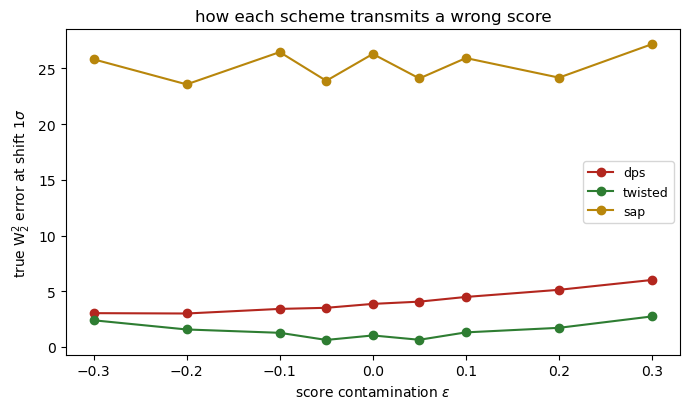

In [4]:
ms = [r for r in rows("t1_misspec.jsonl") if r.get("dim") == 64]
core = [r for r in rows("t1_core.jsonl") if r.get("dim") == 64
        and r.get("eps", 0) == 0 and r.get("shift") == 1.0]
fig, ax = plt.subplots(figsize=(7, 4.2))
for s, color in (("dps", "#b3261e"), ("twisted", "#2e7d32"),
                 ("sap", "#b8860b")):
    eps_vals = sorted({r["eps"] for r in ms if r["sampler"] == s})
    pts = []
    for e in eps_vals:
        w = [r["w2"] for r in ms if r["sampler"] == s and r["eps"] == e
             and r.get("shift") == 1.0]
        if w:
            pts.append((e, np.median(w)))
    e0 = [r["w2"] for r in core if r["sampler"] == s]
    if e0:
        pts.append((0.0, np.median(e0)))
    pts.sort()
    if pts:
        ax.plot([p[0] for p in pts], [p[1] for p in pts], "o-",
                color=color, label=s)
ax.set_xlabel("score contamination $\\varepsilon$")
ax.set_ylabel("true W$_2^2$ error at shift 1$\sigma$")
ax.set_title("how each scheme transmits a wrong score")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**The trap.** Because dps and the contamination can partially cancel,
there is a special contamination $\varepsilon^*$ where the first-look
diagnostic reads perfectly clean while the pipeline is doubly broken. The
temperature diagnostic below is $\gamma^*$ again: the steering strength the
samples express, so 1.00 reads as "faithful".

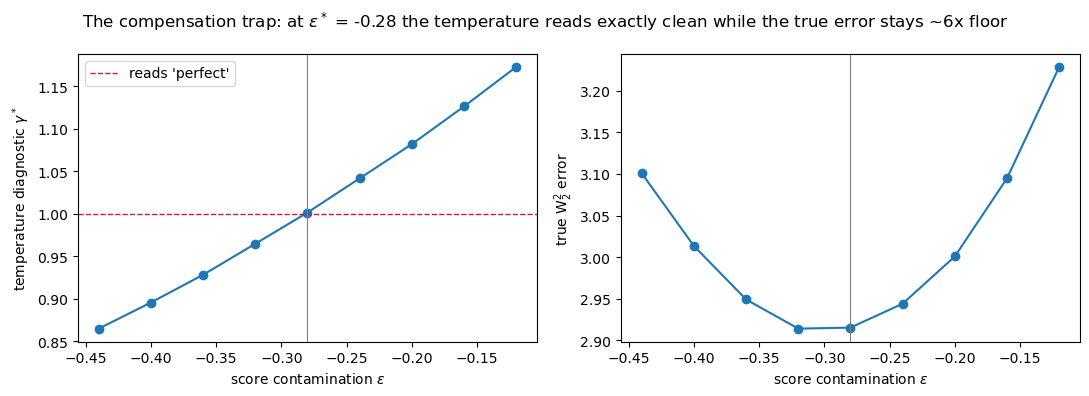

In [5]:
es = rows("eps_star.jsonl")
by_eps = defaultdict(lambda: defaultdict(list))
for r in es:
    if r["sampler"] == "dps":
        by_eps[r["eps"]]["g"].append(r["gamma_star"])
        by_eps[r["eps"]]["w"].append(r["w2"])
eps_grid = sorted(by_eps)
if eps_grid:
    g = [np.median(by_eps[e]["g"]) for e in eps_grid]
    w = [np.median(by_eps[e]["w"]) for e in eps_grid]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(eps_grid, g, "o-")
    axes[0].axhline(1.0, color="crimson", lw=1, ls="--",
                    label="reads 'perfect'")
    axes[0].set_xlabel("score contamination $\\varepsilon$")
    axes[0].set_ylabel("temperature diagnostic $\gamma^*$")
    axes[0].legend()
    axes[1].plot(eps_grid, w, "o-")
    axes[1].set_xlabel("score contamination $\\varepsilon$")
    axes[1].set_ylabel("true W$_2^2$ error")
    for ax in axes:
        ax.axvline(-0.28, color="gray", lw=0.8)
    fig.suptitle("The compensation trap: at $\\varepsilon^*$ = -0.28 the "
                 "temperature reads exactly clean while the true error "
                 "stays ~6x floor")
    plt.tight_layout()
    plt.show()

This doubly-wrong-but-clean-looking configuration is carried into
notebook 03 as the hardest test for the diagnostics. Sample-based tests do
catch it, though they need several times their usual budget. Whether the
proposed runtime certificates catch it is one of the questions the trial
answers.